<font color= 'darkblue'>
    
# 📺YouTube Ad Revenue Prediction - Monetization Modeler

## Project Overview

This project develops a machine learning regression solution to predict
YouTube advertising revenue (`ad_revenue_usd`) using video performance,
engagement, audience, device, country, and content-related features.

The project covers:

- Data understanding and cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Categorical encoding
- Regression model development
- Model evaluation and comparison
- Feature interpretation
- Business insights
- Final model deployment through Streamlit

### Importing nessary libraries

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib

### Load Dataset

In [48]:
df=pd.read_csv(r"C:\Users\MARY PRETHI\Downloads\youtube_ad_revenue_dataset (1).csv")

### Data Understanding

The dataset is inspected using shape, data types, descriptive statistics,
and sample records to understand its structure and variables.

In [49]:
df.head(10)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
5,vid_5000,2025-03-31 10:50:40.993199,10002,843.0,159.0,35131.756228,12.491826,541268,Music,TV,CA,234.965996
6,vid_2041,2024-12-10 10:50:40.993199,9989,1944.0,160.0,35380.070908,6.520903,193736,Music,Mobile,IN,255.009412
7,vid_3623,2025-04-05 10:50:40.993199,10051,784.0,458.0,19263.212580,24.586121,823662,Entertainment,Tablet,US,164.533455
8,vid_750,2025-02-17 10:50:40.993199,9934,292.0,88.0,NaN,5.946666,58437,Entertainment,Desktop,UK,336.409856
9,vid_4434,2025-04-16 10:50:40.993199,10051,NaN,61.0,40011.579945,24.454723,103872,Tech,Tablet,DE,246.711883


In [5]:
df.shape

(122400, 12)

In [6]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [8]:
df['ad_revenue_usd'].value_counts()

ad_revenue_usd
269.633873    2
349.712371    2
162.109810    2
198.752695    2
171.139882    2
             ..
144.559457    1
211.721746    1
199.164255    1
212.831209    1
289.808087    1
Name: count, Length: 120000, dtype: int64

### Data Cleaning

#### Dealing with duplicates

In [50]:
dupes=df.duplicated()
sum(dupes)

2400

#### drop duplicates


In [51]:
df=df.drop_duplicates()

In [52]:
 df.duplicated().sum()

np.int64(0)

### Correlation among pairs of continuous variables

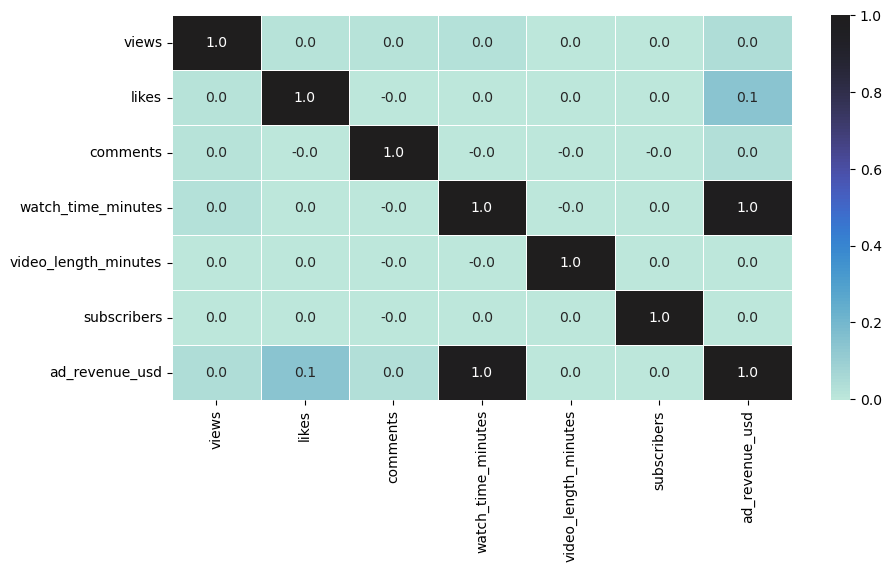

In [53]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=.5, fmt= '.1f', center = 1 )  # heatmap
plt.show()

<font color = 'darkblue'>

* from the above heatmap we can see watch_time_minutes and ad_revenue_usd is the only pair with most correlation

### Handling missing values

### Standard missing values

In [13]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [14]:
df1=pd.DataFrame({'value' : df['likes'], 'Missing?' : df['likes'].isnull()}) 
df1.head(50)

,value,Missing?
0,1221.0,False
1,642.0,False
2,1979.0,False
3,1191.0,False
4,1858.0,False
5,843.0,False
6,1944.0,False
7,784.0,False
8,292.0,False
9,NaN,True


In [15]:
df.dropna(inplace=True)           # drop the missing values
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [16]:
df.isnull().any()

video_id                False
date                    False
views                   False
likes                   False
comments                False
watch_time_minutes      False
video_length_minutes    False
subscribers             False
category                False
device                  False
country                 False
ad_revenue_usd          False
dtype: bool

In [17]:
df.value_counts().sum()

np.int64(102879)

### Handling outliers 

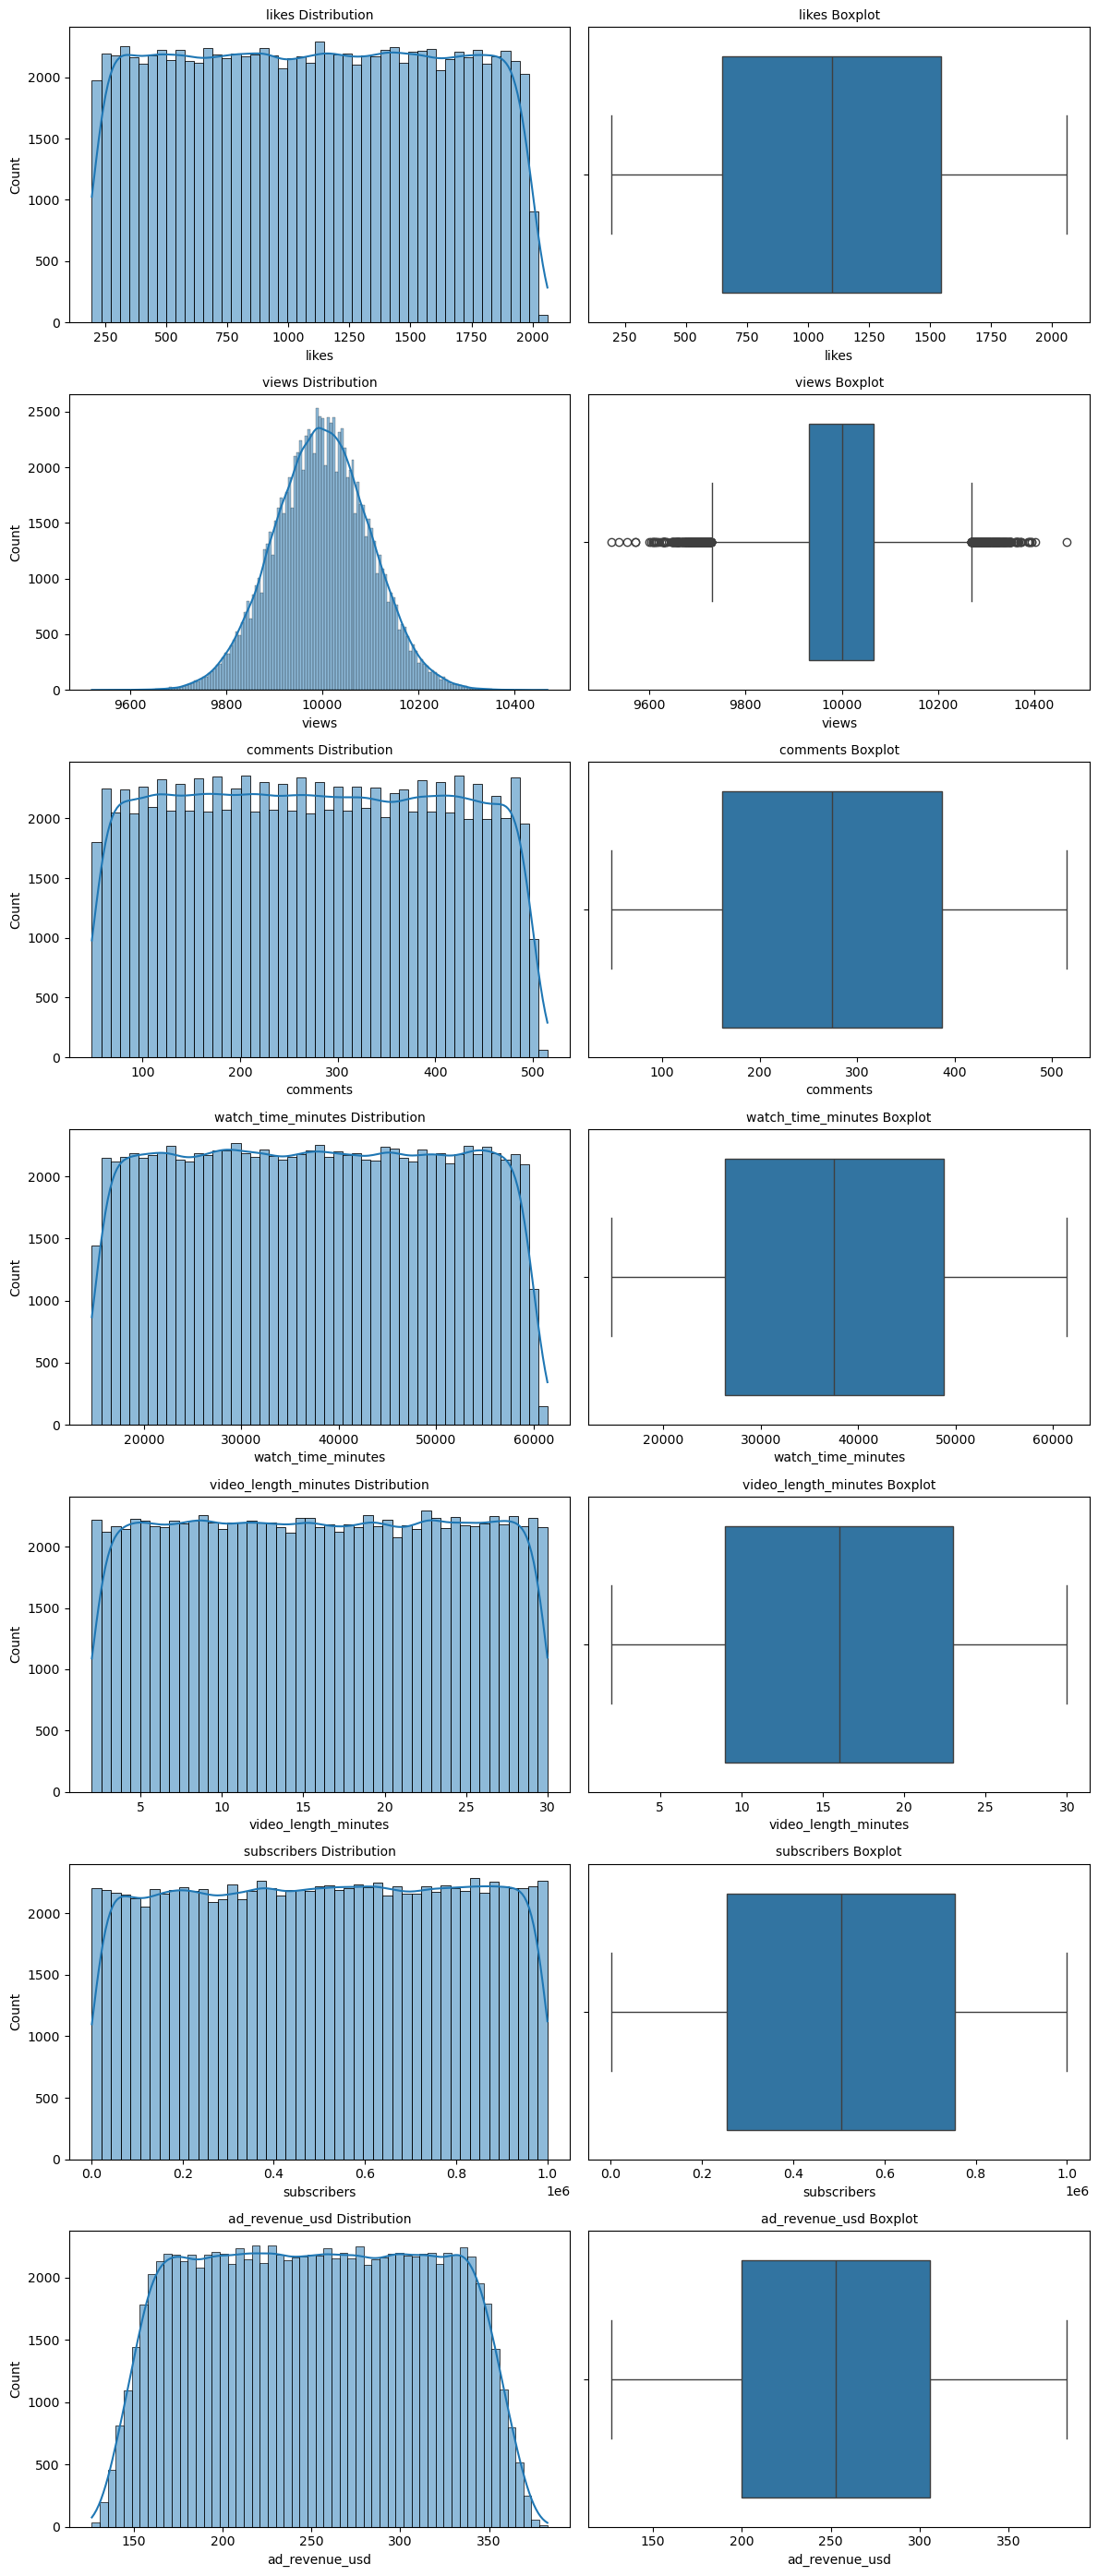

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "likes",
    "views",
    "comments",
    "watch_time_minutes",
    "video_length_minutes",
    "subscribers",
    "ad_revenue_usd"
]

fig, axes = plt.subplots(
    nrows=len(numeric_cols),
    ncols=2,
    figsize=(12, 28)
)

for i, col in enumerate(numeric_cols):

    # Distribution plot
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(
        f"{col} Distribution",
        fontsize=10
    )

    # Boxplot
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(
        f"{col} Boxplot",
        fontsize=10
    )

plt.tight_layout()
plt.show()

<font color= 'darkblue'>

from the above boxplot, views column only getting outliers.

In [23]:
Q1 = df["views"].quantile(0.25)
Q3 = df["views"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[
    (df["views"] < lower_bound) |
    (df["views"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage:", len(outliers) / len(df) * 100)

Q1: 9932.0
Q3: 10067.0
IQR: 135.0
Lower Bound: 9729.5
Upper Bound: 10269.5
Number of outliers: 709
Percentage: 0.689159109244841


In [24]:
print("Views skewness:", df["views"].skew())

Views skewness: -0.0009698525954402037


In [25]:
df["views"].describe()

count    102879.000000
mean       9999.703380
std          99.919143
min        9521.000000
25%        9932.000000
50%       10000.000000
75%       10067.000000
max       10468.000000
Name: views, dtype: float64

In [26]:
print("Minimum:", df["views"].min())
print("Maximum:", df["views"].max())

Minimum: 9521
Maximum: 10468


<font color = 'darkblue'>

Outlier Analysis – Views

* The IQR method identified 865 observations (0.72%) as potential outliers in the views variable.
    
* However, the views distribution is approximately symmetric, with a skewness close to zero (-0.0029). The observed values range from 9,521 to 10,468.

* Since these observations fall within a reasonable range and do not indicate extreme or unrealistic values, they were retained rather than removed.

### Feature Engineering

#### Engagement Rate

<font color= 'darkblue'>

An engagement rate feature is created from likes, comments, and views
to represent audience interaction relative to video views.

In [28]:
df["engagement_rate"] = (df["likes"] + df["comments"]) / df["views"]      # new column

### Encoding categorical variable

### One Hot Encoding

#### Categorical Encoding

<font color= 'darkblue'>

The categorical variables `category`, `device`, and `country` are
converted into numerical dummy variables using One-Hot Encoding.

`drop_first=True` is used to avoid redundant dummy variables and
reduce multicollinearity.

Reference categories:

- Education — Category
- Desktop — Device
- AU — Country

In [ ]:
df.info()

In [30]:
df['category'].value_counts()

category
Education        17322
Tech             17198
Music            17196
Gaming           17098
Entertainment    17096
Lifestyle        16969
Name: count, dtype: int64

In [31]:
df2 = pd.get_dummies(
    df,
    columns=["category", "device", "country"],
     dtype= int ,drop_first=True
)

In [32]:
df2.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,engagement_rate,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,0.155093,...,0,0,0,1,0,0,0,1,0,0
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,0.098632,...,0,0,0,0,1,1,0,0,0,0
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,0.214519,...,0,0,0,1,0,1,0,0,0,0
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,0.142814,...,0,0,1,0,0,0,0,0,1,0
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,0.236121,...,0,0,1,0,0,1,0,0,0,0


In [33]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102879 entries, 0 to 122398
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   video_id                102879 non-null  object 
 1   date                    102879 non-null  object 
 2   views                   102879 non-null  int64  
 3   likes                   102879 non-null  float64
 4   comments                102879 non-null  float64
 5   watch_time_minutes      102879 non-null  float64
 6   video_length_minutes    102879 non-null  float64
 7   subscribers             102879 non-null  int64  
 8   ad_revenue_usd          102879 non-null  float64
 9   engagement_rate         102879 non-null  float64
 10  category_Entertainment  102879 non-null  int64  
 11  category_Gaming         102879 non-null  int64  
 12  category_Lifestyle      102879 non-null  int64  
 13  category_Music          102879 non-null  int64  
 14  category_Tech           1

### EDA

####  Revenue Distribution 

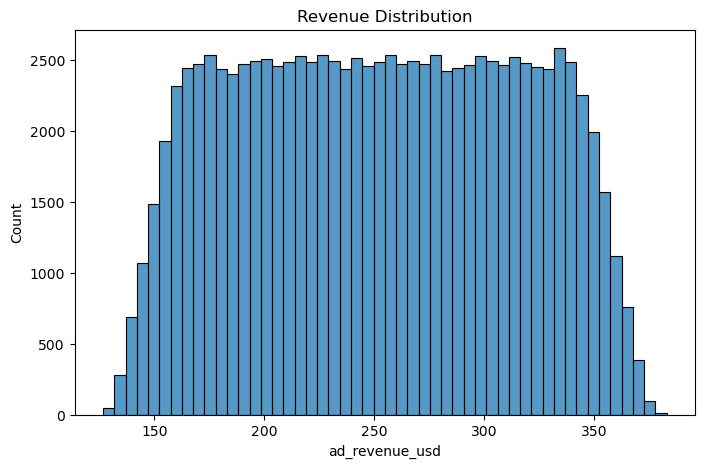

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["ad_revenue_usd"], bins=50)
plt.title("Revenue Distribution")
plt.show()

#### Correlation heatmap

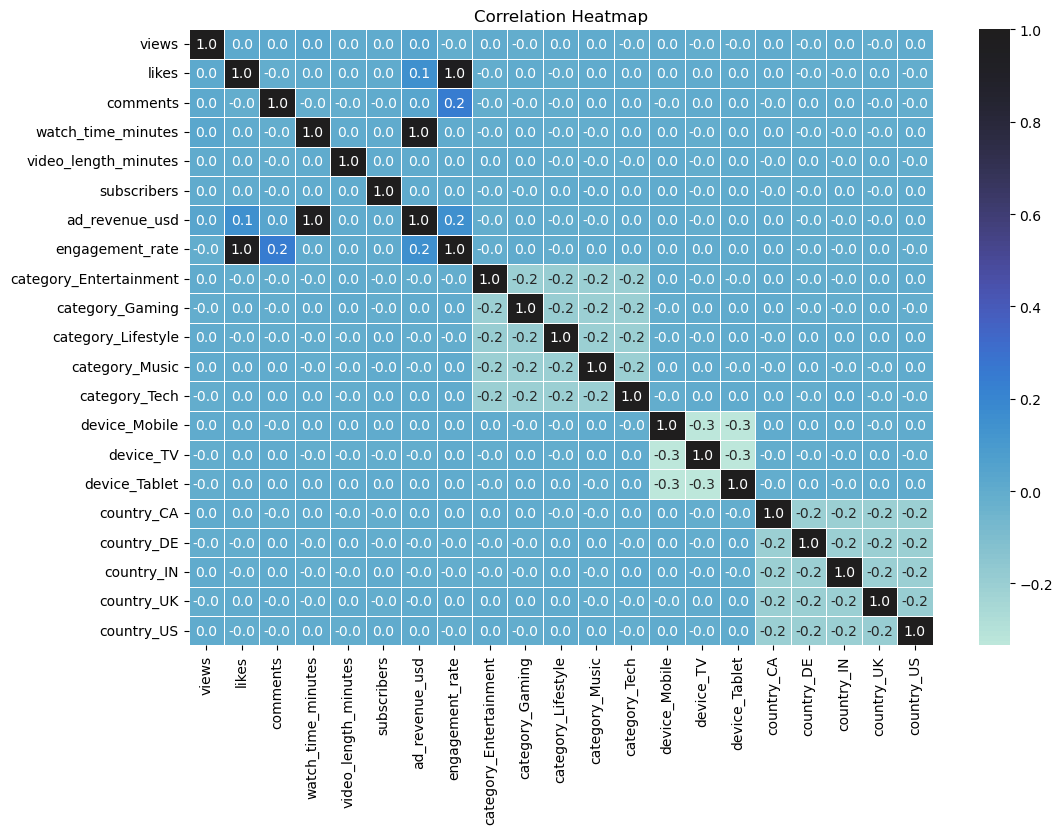

In [36]:
plt.figure(figsize=(12,8))
sns.heatmap(df2.corr(numeric_only=True), annot=True, linewidths=0.5, fmt= '.1f', center = 1 )
plt.title("Correlation Heatmap")
plt.show()

<font color= 'darkblue'>

Engagement rate improves monetization

#### Views vs Revenue

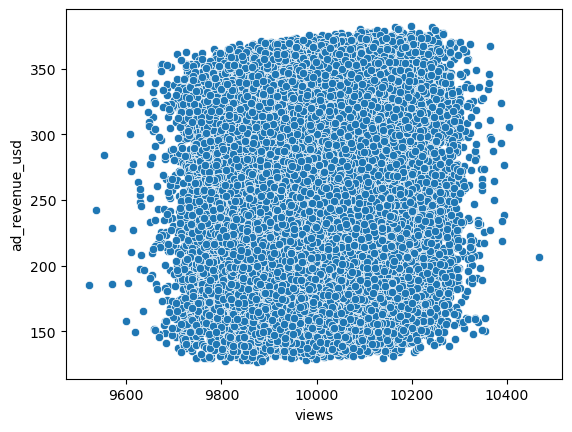

In [38]:
sns.scatterplot(x=df["views"], y=df["ad_revenue_usd"])
plt.show()

<font color= 'darkblue'>

Views strongly influence ad revenue

#### Category-wise Revenue

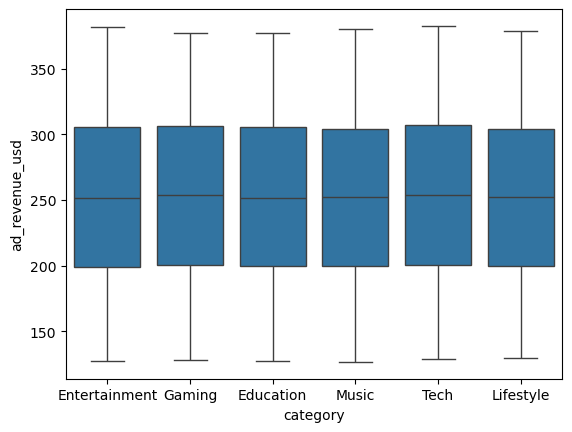

In [40]:
sns.boxplot(x=df["category"], y=df["ad_revenue_usd"])
plt.show()

### DEFINE FEATURES & TARGET

In [41]:
y = df2["ad_revenue_usd"]              # target variable

In [42]:
X = df2.drop(columns=["ad_revenue_usd", "video_id", "date"])

### Train Test Split

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split (X, y,test_size=0.3, random_state=100)

In [45]:
X_train.shape

(72015, 20)

In [46]:
X_test.shape

(30864, 20)

In [40]:
X_test.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,engagement_rate,category_Entertainment,category_Gaming,category_Lifestyle,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
17019,10229,889.0,79.0,20288.770077,8.674118,388869,0.094633,0,0,1,0,0,0,0,1,1,0,0,0,0
31699,9966,480.0,307.0,43301.175880,12.138855,357138,0.078968,1,0,0,0,0,0,1,0,0,0,0,1,0
17253,10054,206.0,437.0,57713.306246,11.985175,231471,0.063955,0,0,0,0,1,0,0,0,0,0,1,0,0
45837,10062,414.0,153.0,42458.071083,9.480907,288120,0.056351,0,0,1,0,0,1,0,0,1,0,0,0,0
31355,10070,1622.0,362.0,45373.535417,9.813871,904859,0.197021,0,1,0,0,0,0,1,0,0,0,0,1,0


In [41]:
y_train.shape

(72015,)

In [42]:
y_test.shape

(30864,)

### Linear Regression

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
lr = LinearRegression()

In [45]:
lr.fit(X_train,y_train)

LinearRegression()

In [46]:
# The coefficients
print('Coefficients: \n', lr.coef_)

Coefficients: 
 [ 5.21039303e-03  1.71873523e-02  1.71873523e-02  4.71453568e-03
  3.62370788e-18  4.73571039e-18  7.86218191e-13  3.81731159e-15
  6.70243350e-16  9.50874248e-16 -8.23446362e-17  5.18814191e-16
 -1.21574559e-16 -9.14083992e-16 -3.80812924e-16 -1.32568035e-16
 -1.15561775e-16 -4.40493650e-16 -1.30633678e-16 -3.44391616e-16]


### Predict the model

In [49]:
lr_pred_train = lr.predict( X_train)

In [50]:
lr_pred_train

array([270.32346049, 273.88073942, 269.06770197, ..., 240.23641573,
       232.42315826, 165.62380964], shape=(72015,))

In [52]:
lr_pred_test = lr.predict( X_test)

In [53]:
lr_pred_test


array([165.58659772, 269.59816181, 335.52820049, ..., 248.41879977,
       278.05811548, 325.49354129], shape=(30864,))

In [54]:
from sklearn import metrics

In [55]:
train_score=metrics.r2_score(y_train,lr_pred_train)
train_score

1.0

In [56]:
test_score=metrics.r2_score(y_test,lr_pred_test)
linear_r2=test_score
linear_r2

1.0

### Evaluate the model

In [57]:
from sklearn import metrics

linear_mae= metrics.mean_absolute_error(y_test, lr_pred_test)
linear_mse= metrics.mean_squared_error(y_test, lr_pred_test)
linear_rmse= np.sqrt(metrics.mean_squared_error(y_test, lr_pred_test))

print("Linear Regression")
print("R²:", linear_r2)
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)

Linear Regression
R²: 1.0
MAE: 1.1785248199259114e-12
MSE: 1.8664510457893267e-24
RMSE: 1.3661811906878703e-12


### Ridge Regression

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()

In [60]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
print(X_train_scaled[:5])

[[-0.5490841  -0.31696145 -0.2277068   0.34708769 -0.63381526 -1.10986551
  -0.35104427  2.23578857 -0.44729184 -0.44556942 -0.44709063 -0.44776121
   1.73730991 -0.57784733 -0.57679976 -0.45126517 -0.44726948 -0.4492353
  -0.44686703  2.25828795]
 [-1.08053052  0.43558842 -0.25081066  0.30083579  0.50591563 -1.72475441
   0.39403761 -0.44726948 -0.44729184 -0.44556942  2.23668297 -0.44776121
  -0.57560254  1.73056091 -0.57679976 -0.45126517 -0.44726948 -0.4492353
  -0.44686703  2.25828795]
 [-0.06777413 -0.29001593  0.80426571  0.28102644  0.93802565 -0.9035403
  -0.08482568 -0.44726948 -0.44729184 -0.44556942 -0.44709063  2.23333327
  -0.57560254  1.73056091 -0.57679976 -0.45126517 -0.44726948  2.22600494
  -0.44686703 -0.44281333]
 [ 0.4636723  -0.93285904  1.1123172  -1.23933721  0.88115487 -0.02761758
  -0.64497805  2.23578857 -0.44729184 -0.44556942 -0.44709063 -0.44776121
   1.73730991 -0.57784733 -0.57679976 -0.45126517 -0.44726948 -0.4492353
  -0.44686703 -0.44281333]
 [-0.488

In [62]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
parameters={'alpha':[0.1,1,5,10,20,30,35,40,45,50,55,100]}## Appllying Grid Search
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55,
                                   100]},
             scoring='neg_mean_squared_error')

In [63]:
print(ridge_regressor.best_params_)## Best value for the Parameter

{'alpha': 0.1}


In [64]:
from sklearn.linear_model import Ridge## Building the Model with the best parameter value
ridge_regressor = Ridge(alpha = 0.1)
ridge_regressor.fit(X_train_scaled, y_train)

Ridge(alpha=0.1)

In [65]:
ridge_pred_train=ridge_regressor.predict(X_train_scaled)

In [66]:
ridge_pred_test=ridge_regressor.predict(X_test_scaled)

In [67]:
# R square on training data
train_score=metrics.r2_score(y_train,ridge_pred_train)
train_score

0.9999999995957831

In [72]:
test_score=metrics.r2_score(y_test,ridge_pred_test)
ridge_r2 = test_score
ridge_r2

0.9999999995865548

In [74]:
lr.coef_

array([ 5.21039303e-03,  1.71873523e-02,  1.71873523e-02,  4.71453568e-03,
        3.62370788e-18,  4.73571039e-18,  7.86218191e-13,  3.81731159e-15,
        6.70243350e-16,  9.50874248e-16, -8.23446362e-17,  5.18814191e-16,
       -1.21574559e-16, -9.14083992e-16, -3.80812924e-16, -1.32568035e-16,
       -1.15561775e-16, -4.40493650e-16, -1.30633678e-16, -3.44391616e-16])

In [75]:
ridge_regressor.coef_

array([ 5.22818206e-01,  8.80879995e+00,  2.20146645e+00,  6.13003901e+01,
       -1.70351682e-06,  2.03698509e-06,  1.24759583e-01,  1.51602026e-05,
        1.09254385e-05,  7.53152226e-06,  1.09473012e-05,  8.16836668e-06,
        1.20555965e-05,  2.36367439e-06,  4.51616803e-07,  5.80869198e-06,
       -1.96101897e-06, -1.68188031e-06, -4.32466340e-06,  3.78872345e-06])

In [76]:
# Let us explore the coefficients for each of the independent attributes

for idx, col_name in enumerate(X_train.columns):
    print(f"The coefficient for {col_name} is {ridge_regressor.coef_[idx]}")

The coefficient for views is 0.5228182057900794
The coefficient for likes is 8.808799948393043
The coefficient for comments is 2.201466445389847
The coefficient for watch_time_minutes is 61.30039010027267
The coefficient for video_length_minutes is -1.703516824442432e-06
The coefficient for subscribers is 2.036985094907743e-06
The coefficient for engagement_rate is 0.12475958349032482
The coefficient for category_Entertainment is 1.5160202595123585e-05
The coefficient for category_Gaming is 1.0925438471534805e-05
The coefficient for category_Lifestyle is 7.53152225864892e-06
The coefficient for category_Music is 1.0947301189452243e-05
The coefficient for category_Tech is 8.168366681812284e-06
The coefficient for device_Mobile is 1.2055596539643128e-05
The coefficient for device_TV is 2.363674391177581e-06
The coefficient for device_Tablet is 4.5161680287207903e-07
The coefficient for country_CA is 5.80869198328347e-06
The coefficient for country_DE is -1.9610189671383847e-06
The coeffi

In [77]:

ridge_mae= mean_absolute_error(y_test, ridge_pred_test)
ridge_mse= mean_squared_error(y_test, ridge_pred_test)
ridge_rmse= np.sqrt(mean_squared_error(y_test, ridge_pred_test))

print("Ridge Regression")
print("R²:", ridge_r2)
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)

Ridge Regression
R²: 0.9999999995865548
MAE: 0.0008611533295191572
MSE: 1.5799907040048525e-06
RMSE: 0.001256976811243888


### Laso Regression

In [78]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()
parameters={'alpha':[0.1,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

lasso_regressor.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.1, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55,
                                   100]},
             scoring='neg_mean_squared_error')

In [79]:
lasso_regressor.best_params_

{'alpha': 0.1}

In [80]:
from sklearn.linear_model import Lasso
lasso_regressor = Lasso(alpha =  0.1 )
lasso_regressor.fit(X_train_scaled,y_train)

Lasso(alpha=0.1)

In [81]:
lasso_pred_train=lasso_regressor.predict(X_train_scaled)

In [82]:
lasso_pred_test=lasso_regressor.predict(X_test_scaled)

In [83]:
# R square on training data
train_score=metrics.r2_score(y_train,lasso_pred_train)
train_score

0.9999900906145123

In [84]:
# R square on training data
test_score=metrics.r2_score(y_test,lasso_pred_test)
lasso_r2 = test_score
lasso_r2

0.9999901296534122

In [85]:
lasso_regressor.coef_

array([ 0.6552894 ,  0.0998422 ,  0.        , 61.20445502,  0.        ,
        0.        ,  8.99723005, -0.        ,  0.        , -0.        ,
        0.        ,  0.        ,  0.        , -0.        ,  0.        ,
        0.        , -0.        ,  0.        , -0.        ,  0.        ])

In [86]:

lasso_mae= mean_absolute_error(y_test, lasso_pred_test)
lasso_mse= mean_squared_error(y_test, lasso_pred_test)
lasso_rmse= np.sqrt(mean_squared_error(y_test, lasso_pred_test))

print("Lasso Regression")
print("R²:", lasso_r2)
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)

Lasso Regression
R²: 0.9999901296534122
MAE: 0.14963568530860535
MSE: 0.03771977045403554
RMSE: 0.19421578322586333


### Random Forest Regression

In [87]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=30,
    n_jobs=-1
)

rf_regressor.fit(X_train, y_train)



RandomForestRegressor(n_jobs=-1, random_state=30)

In [88]:
rf_pred_test = rf_regressor.predict(X_test)

In [89]:
rf_pred_train = rf_regressor.predict(X_train)

In [90]:
# R square on training data
train_score=metrics.r2_score(y_train,rf_pred_train)
train_score

0.9999923135751417

In [91]:
# R square on testing data
test_score=metrics.r2_score(y_test,rf_pred_test)
rf_r2 = test_score
rf_r2

0.9999466373432602

In [92]:
from sklearn import metrics


rf_mae= metrics.mean_absolute_error(y_test, rf_pred_test)
rf_mse= metrics.mean_squared_error(y_test, rf_pred_test)
rf_rmse= np.sqrt(metrics.mean_squared_error(y_test, rf_pred_test))

print("Random Forest Regression")
print("R²:", rf_r2)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)

Random Forest Regression
R²: 0.9999466373432602
MAE: 0.3274777633259299
MSE: 0.20392669549469034
RMSE: 0.4515824348828133


### Gradient Boosting

In [93]:
from sklearn.ensemble import GradientBoostingRegressor

gb_regressor = GradientBoostingRegressor(
    random_state=42
)

gb_regressor.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [94]:
gb_pred_test = gb_regressor.predict(X_test)

In [95]:
gb_pred_train = gb_regressor.predict(X_train)

In [96]:
# R square on training data
train_score=metrics.r2_score(y_train,gb_pred_train)
train_score

0.9998247387089937

In [97]:
# R square on testing data
test_score=metrics.r2_score(y_test,gb_pred_test)
gb_r2 = test_score
gb_r2

0.9998106729293564

In [99]:
from sklearn import metrics

gb_mae= metrics.mean_absolute_error(y_test, gb_pred_test)
gb_mse= metrics.mean_squared_error(y_test, gb_pred_test)
gb_rmse= np.sqrt(metrics.mean_squared_error(y_test, gb_pred_test))

print("Gradient Boosting")
print("R²:", gb_r2)
print("MAE:", gb_mae)
print("MSE:", gb_mse)
print("RMSE:", gb_rmse)

Gradient Boosting
R²: 0.9998106729293564
MAE: 0.6695349948037791
MSE: 0.723518022579972
RMSE: 0.850598626015803


### Final Result

In [100]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "R²": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        gb_r2
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        gb_mae
    ],

    "MSE": [
        linear_mse,
        ridge_mse,
        lasso_mse,
        rf_mse,
        gb_mse
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results_df

,Model,R²,MAE,MSE,RMSE
0,Linear Regression,1.000000,1.178525e-12,1.866451e-24,1.366181e-12
1,Ridge Regression,1.000000,8.611533e-04,1.579991e-06,1.256977e-03
2,Lasso Regression,0.999990,1.496357e-01,3.771977e-02,1.942158e-01
3,Random Forest,0.999947,3.274778e-01,2.039267e-01,4.515824e-01
4,Gradient Boosting,0.999811,6.695350e-01,7.235180e-01,8.505986e-01


<font color = 'darkblue'>

Model Comparison and Selection

* Five regression models—Linear Regression, Ridge Regression, Lasso Regression, Random Forest Regression, and Gradient Boosting Regression—were trained to predict ad_revenue_usd. The models were evaluated using R², MAE, MSE, and RMSE.

* Linear Regression achieved the best overall performance, with an R² score of 1.000000 and extremely low MAE and RMSE values. Ridge Regression also performed exceptionally well, while Lasso Regression, Random Forest, and Gradient Boosting showed slightly higher prediction errors.

* Based on the evaluation metrics, <font color = 'green'>Linear Regression <font color = 'darkblue'>was selected as the final model for the application.

### Conclusion

<font color= 'green'>

Linear Regression was selected as the final model because it achieved the strongest overall performance, with an R² of approximately 1.00 and extremely low error metrics.

### Feature Interpretation

In [107]:
# Get feature names
feature_names = X_train.columns

# Get coefficients
coefficients = lr.coef_

# Create a dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})


coef_df

,Feature,Coefficient
0,views,5.210393e-03
1,likes,1.718735e-02
2,comments,1.718735e-02
3,watch_time_minutes,4.714536e-03
4,video_length_minutes,3.623708e-18
5,subscribers,4.735710e-18
6,engagement_rate,7.862182e-13
7,category_Entertainment,3.817312e-15
8,category_Gaming,6.702433e-16
9,category_Lifestyle,9.508742e-16


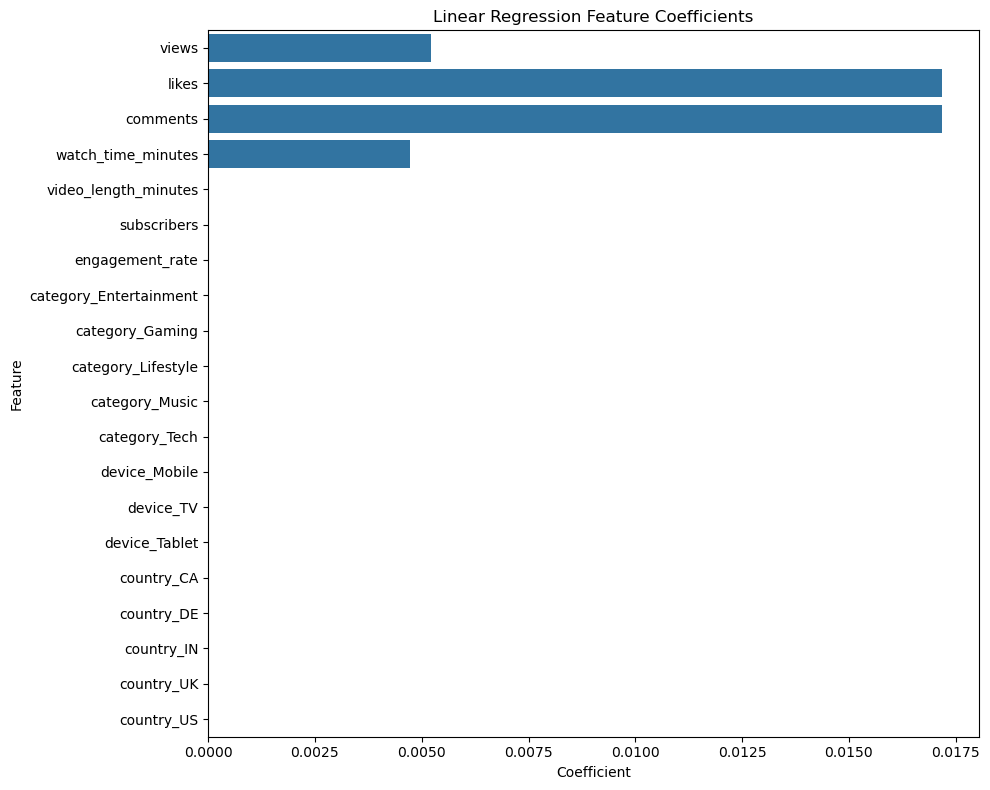

In [108]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [109]:
corr_with_revenue = (
    df.select_dtypes(include="number")
      .corr()["ad_revenue_usd"]
      .sort_values(ascending=False)
)

corr_with_revenue

ad_revenue_usd          1.000000
watch_time_minutes      0.988852
engagement_rate         0.151485
likes                   0.148323
views                   0.037946
comments                0.035002
subscribers             0.004302
video_length_minutes    0.001470
Name: ad_revenue_usd, dtype: float64

In [112]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_regressor.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
3,watch_time_minutes,0.978151
6,engagement_rate,0.021458
1,likes,0.000256
0,views,0.000099
5,subscribers,0.000008
4,video_length_minutes,0.000008
2,comments,0.000008
14,device_Tablet,0.000001
12,device_Mobile,0.000001
13,device_TV,0.000001


<font color = 'darkblue'>

* Feature interpretation was performed using Linear Regression coefficients and Random Forest feature importance. Linear Regression showed positive coefficients for comments, likes, views, and watch_time_minutes, indicating positive modeled relationships with ad revenue.

* Random Forest feature importance identified watch_time_minutes as the dominant predictive feature, with an importance of approximately 0.978, followed by engagement_rate with approximately 0.0215. The remaining variables had relatively small importance values.

* The strong importance of watch_time_minutes is consistent with the exploratory correlation analysis, where watch_time_minutes had a correlation of approximately 0.989 with ad_revenue_usd. Therefore, <font color = 'green'>watch time appears to be the strongest predictor of ad revenue in this dataset.

### Business Insights

#### Key Findings

<font color= 'darkblue'>

1. **Watch time is the strongest predictor**
   
   Random Forest feature importance assigned approximately 97.8% of its
   importance score to `watch_time_minutes`.

2. **Watch time has a very strong relationship with revenue**
   
   The correlation between `watch_time_minutes` and `ad_revenue_usd`
   is approximately 0.989.

3. **Engagement-related variables are useful**
   
   Likes, comments, views, and engagement rate provide additional
   information about predicted revenue.

4. **Categorical variables have relatively small predictive importance**
   
   Category, device, and country contributed much less to the final
   tree-based feature importance compared with watch time.

5. **The dataset is synthetic**
   
   Therefore, these relationships should be interpreted as model-based
   associations rather than causal conclusions.

### Save Final Model

In [122]:
import joblib

# Save the exact feature names used by the model
feature_names = X.columns.tolist()

# Save model + feature names together
model_bundle = {
    "model": lr,
    "feature_names": feature_names
}

joblib.dump(model_bundle, "linear_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Model Verification

In [123]:
import os

print(os.path.exists("linear_regression_model.pkl"))

True


In [124]:
print(os.path.getsize("linear_regression_model.pkl"), "bytes")

1891 bytes


In [125]:
loaded_bundle = joblib.load("linear_regression_model.pkl")

loaded_model = loaded_bundle["model"]
loaded_features = loaded_bundle["feature_names"]

print(type(loaded_model))
print(len(loaded_features))
print(loaded_features)

<class 'sklearn.linear_model._base.LinearRegression'>
20
['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'engagement_rate', 'category_Entertainment', 'category_Gaming', 'category_Lifestyle', 'category_Music', 'category_Tech', 'device_Mobile', 'device_TV', 'device_Tablet', 'country_CA', 'country_DE', 'country_IN', 'country_UK', 'country_US']


In [126]:
loaded_predictions = loaded_model.predict(X_test)

print("First 10 predictions:")
print(loaded_predictions[:10])

First 10 predictions:
[165.58659772 269.59816181 335.52820049 262.34229439 300.48351636
 313.47683787 233.91287724 320.76130377 230.8281369  346.37119049]


In [127]:
original_predictions = lr.predict(X_test)

print(
    "Predictions identical:",
    np.allclose(
        original_predictions,
        loaded_predictions
    )
)

Predictions identical: True


In [128]:
print("Categories:")
print(df["category"].unique())

print("\nDevices:")
print(df["device"].unique())

print("\nCountries:")
print(df["country"].unique())

print("\nModel features:")
print(X.columns.tolist())

Categories:
['Entertainment' 'Gaming' 'Education' 'Music' 'Tech' 'Lifestyle']

Devices:
['TV' 'Tablet' 'Mobile' 'Desktop']

Countries:
['IN' 'CA' 'UK' 'US' 'AU' 'DE']

Model features:
['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'engagement_rate', 'category_Entertainment', 'category_Gaming', 'category_Lifestyle', 'category_Music', 'category_Tech', 'device_Mobile', 'device_TV', 'device_Tablet', 'country_CA', 'country_DE', 'country_IN', 'country_UK', 'country_US']
